In [1]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.combined_pc_pf_inertial_tb import combinedPCPFInertial
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.localization.particle_filter import particleFilter
from odometry.estimators.motion_models import GyroEncoderIntegrator
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator

/home/david/.cache/pypoetry/virtualenvs/odometry-u_DtWola-py3.11/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
#initial experiments: "/data/radnav/rad_nav_rotate_experiments/wilk_origin_forward/"

dataset = radnavDS(
    dataset_path=DATASET_PATH + "/WILK_BASEMENT_2",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilk_basement.yaml"
)

found 2063 radar samples
found 2063 lidar samples
found 2063 camera samples
found 2063 imu (orientation only) samples
found 2063imu (full data) samples
found 2063 vehicle velocity samples
loaded map from /data/radnav/maps/wilk_basement.yaml
loaded map free space from /data/radnav/maps/wilk_basement.yaml


In [3]:
particle_filter = particleFilter(
    motion_model=GyroEncoderIntegrator(),
    max_particles=1000,
    measurement_sigma=0.5
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6,
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

loaded map with 16346 points
loaded map with 16346 points

loaded map with 16346 free points

gt icp estimated heading:8.324316561799002 deg, pose:[0.07888053 0.1294188 ]


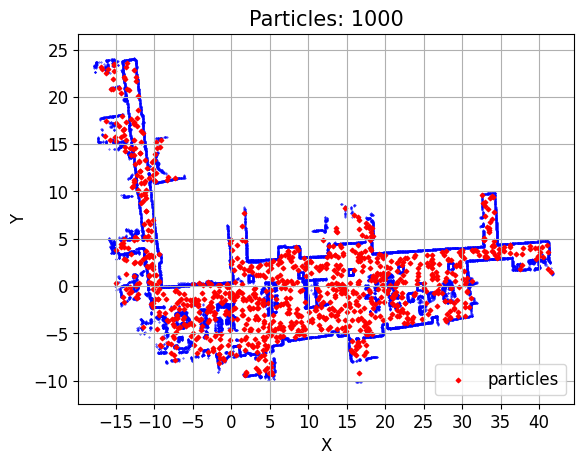

In [6]:
test_bench = combinedPCPFInertial(
    localizer=particle_filter,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    vel_filter_v_thresh = 0.1,
    vel_filter_enabled = True,
    min_static_rejection_radius = 1.5, #was 0.5
    dynamic_cluster_eps = 1.5, #was 3
    dynamic_cluster_min_samples = 15 #was 50
)

start_heading = np.deg2rad(-6.1)
start_pose = np.array([0.03,0.11])

test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

## Old Code (currently integrating into test bench)

In [3]:
#TODO: move to the test bench
particle_filter = particleFilter(max_particles=1000)

#load the map
particle_filter.load_map_point_cloud(map_handler.map_points)
particle_filter.load_map_free_points(map_handler.map_free_points)

loaded map with 16346 points

loaded map with 16346 free points



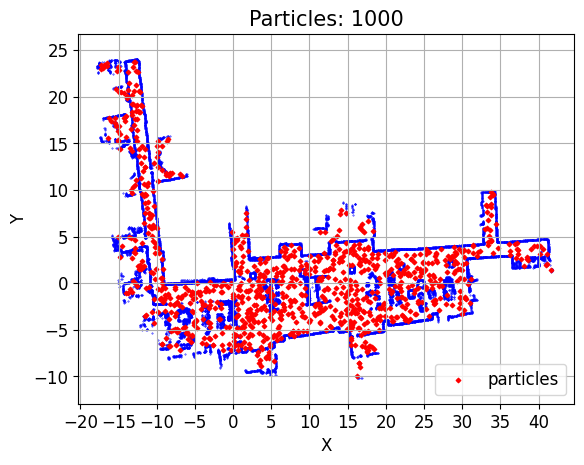

In [4]:
#initialize the particle filter with a uniform set of points
particle_filter.particles = particle_filter.get_uniform_particles_from_free_space(
    hdg_range=(0,2*np.pi),
    N=1000
)

#plot the particles
plotter.plot_particles_on_map(
    particles=particle_filter.particles,
    display_arrows=False,
    show=True
)

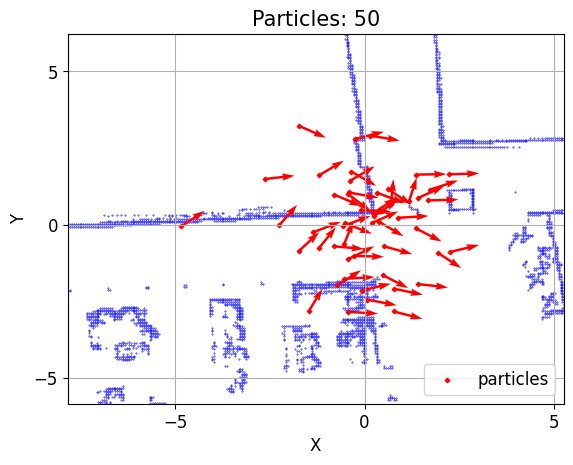

In [5]:
#get a distribution of particles using a gaussian
mean = np.array([0.0,0.0,0.0])
cov = np.zeros((3,3),dtype=float)
np.fill_diagonal(cov,[2.0,2.0,0.25])
particles = particle_filter.get_gaussian_particles(
    mean,
    cov,
    N=50
)

#plot the particles
plotter.plot_particles_on_map(
    particles=particles,
    display_arrows=True,
    show=True
)

In [7]:
points = dataset.get_radar_detections(idx=1)

weights = particle_filter.liklihood_field_measurement_model(
    particles=particle_filter.particles,
    points=points[:,0:2]
)

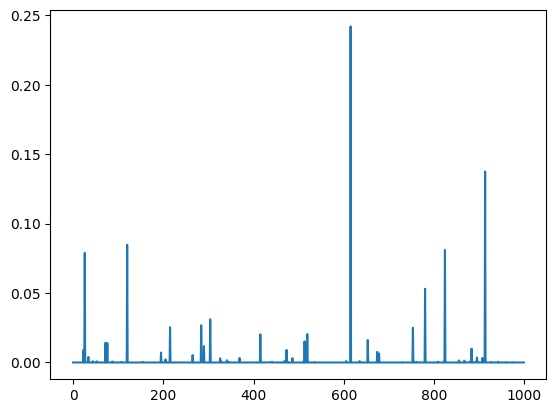

In [8]:
#view the weights
plt.plot(weights)